<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/1234face_mask_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install ultralytics
!pip install roboflow

In [17]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
import os
import argparse
import os
import random
import shutil
import xml.etree.ElementTree as ET
from PIL import Image
import time
import cv2

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import argparse

from ultralytics import YOLO

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

In [19]:
datasetpath="/content/drive/MyDrive/archive (13)/images"


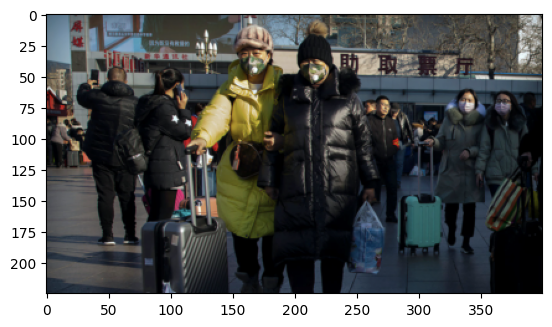

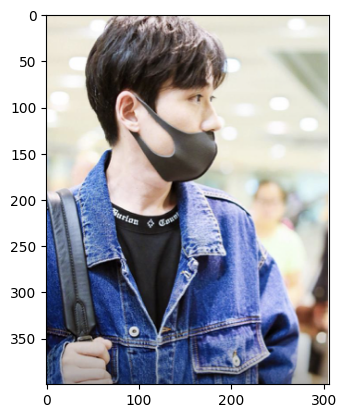

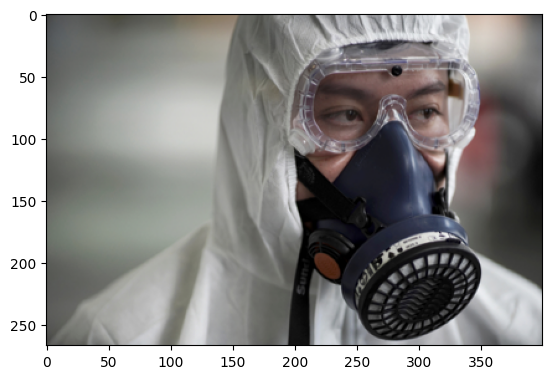

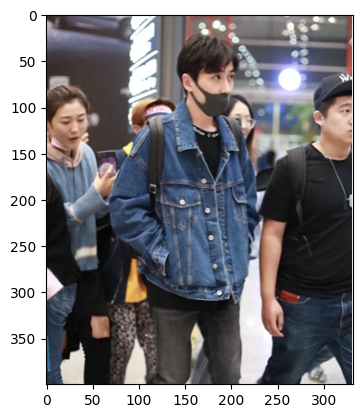

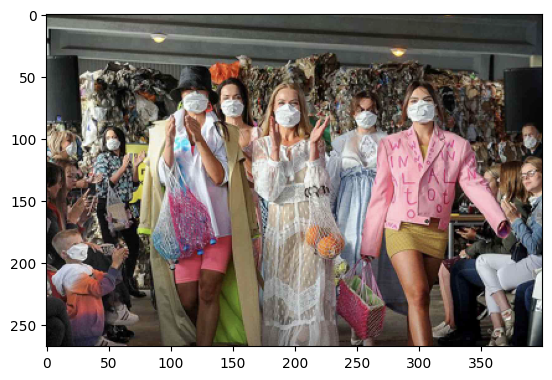

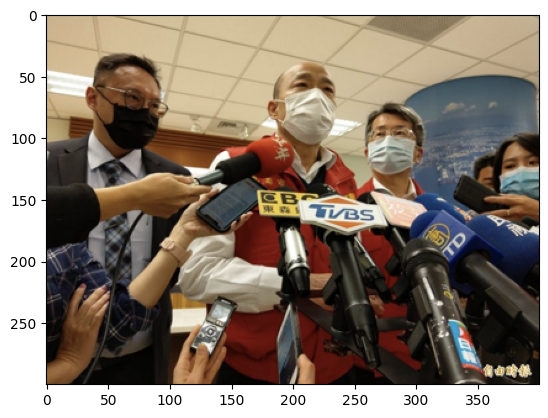

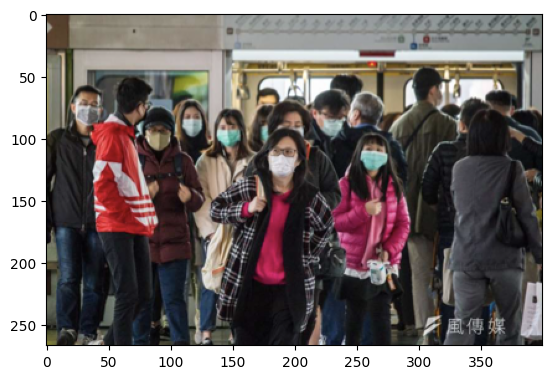

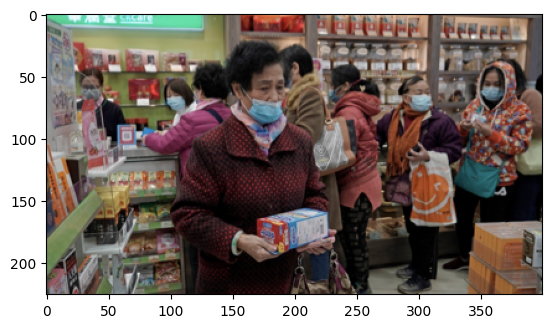

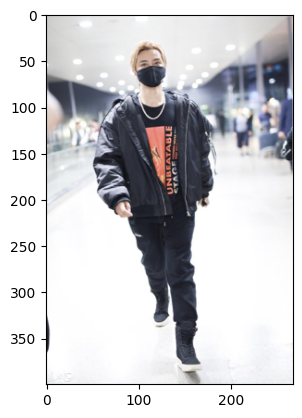

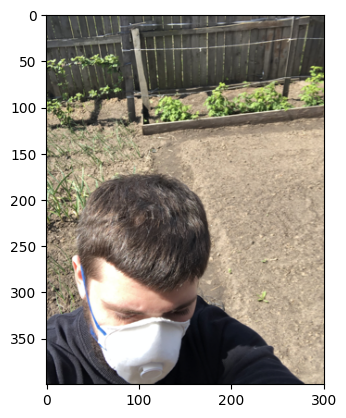

In [20]:
# load and display each  image
files=os.listdir(datasetpath)

for file in files[10:20]:
  if file.endswith((".png", ".jpg", ".jpeg")):
    image_path=os.path.join(datasetpath,file)
    img=Image.open(image_path)
    plt.imshow(img)
    plt.show()




In [21]:
def parse_vol_xml(xml_path):
  tree=ET.parse(xml_path)
  root=tree.getroot()

  size=root.find("size")
  width=int(size.find("width").text)
  height=int(size.find("height").text)

  object=[]

  for obj in root.findall("object"):
    label=obj.find("name").text

    bndbox=obj.find("bndbox")

    xmin=int(bndbox.find("xmin").text)
    ymin=int(bndbox.find("ymin").text)
    xmax=int(bndbox.find("xmax").text)
    ymax=int(bndbox.find("ymax").text)

    object.append([label,xmin,ymin,xmax,ymax])

  return width,height,object



In [22]:
def voc_box_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
  x_center=((xmax+xmin)/2)/img_w
  y_center=((ymax+ymin)/2)/img_h
  width=(xmax-xmin)/img_w
  height=(ymax-ymin)/img_h

  return x_center,y_center,width,height

In [23]:
def discover_class(annotations_dir):
  classes=set()
  for fname in os.listdir(annotations_dir):
      if not fname.endswith(".xml"):
          continue
      _, _, objects = parse_vol_xml(os.path.join(annotations_dir, fname))
      for name, *_ in objects:
          classes.add(name)
          print(classes)
  return sorted(classes)

In [24]:
def convert_and_split(images_dir, annotations_dir, out_dir, val_split=0.15, seed=42):
    xml_files = [f for f in os.listdir(annotations_dir) if f.endswith(".xml")]
    if not xml_files:
        raise RuntimeError(f"No XML files found in {annotations_dir}")

    classes = discover_class(annotations_dir)
    class_to_id = {name: i for i, name in enumerate(classes)}
    print(f"Discovered {len(classes)} classes: {classes}")

    random.seed(seed)
    random.shuffle(xml_files)
    val_count = int(len(xml_files) * val_split)
    val_set = set(xml_files[:val_count])

    for split in ("train", "val"):
        os.makedirs(os.path.join(out_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(out_dir, "labels", split), exist_ok=True)

    skipped = 0
    for xml_name in xml_files:
        basename = os.path.splitext(xml_name)[0]
        xml_path = os.path.join(annotations_dir, xml_name)

        # find matching image (try common extensions)
        img_path = None
        for ext in (".jpg", ".jpeg", ".png"):
            candidate = os.path.join(images_dir, basename + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            print(f"Warning: no image found for {xml_name}, skipping")
            skipped += 1
            continue

        img_w, img_h, objects = parse_vol_xml(xml_path)
        split = "val" if xml_name in val_set else "train"

        # copy image
        img_ext = os.path.splitext(img_path)[1]
        shutil.copy(img_path, os.path.join(out_dir, "images", split, basename + img_ext))

        # write YOLO label file
        label_path = os.path.join(out_dir, "labels", split, basename + ".txt")
        with open(label_path, "w") as f:
            for name, xmin, ymin, xmax, ymax in objects:
                class_id = class_to_id[name]
                xc, yc, w, h = voc_box_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h)
                f.write(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

    # write classes.txt
    with open(os.path.join(out_dir, "classes.txt"), "w") as f:
        f.write("\n".join(classes))

    # write data.yaml for ultralytics
    data_yaml = os.path.join(out_dir, "data.yaml")
    abs_out = os.path.abspath(out_dir)
    with open(data_yaml, "w") as f:
        f.write(f"path: {abs_out}\n")
        f.write("train: images/train\n")
        f.write("val: images/val\n")
        f.write(f"nc: {len(classes)}\n")
        f.write(f"names: {classes}\n")

    print(f"\nDone. {len(xml_files) - skipped} images processed, {skipped} skipped.")
    print(f"Train: {len(xml_files) - val_count - skipped if skipped==0 else 'see above'} | Val: {val_count}")
    print(f"data.yaml written to: {data_yaml}")

In [25]:
convert_and_split("/content/drive/MyDrive/archive (13)/images", "/content/drive/MyDrive/archive (13)/annotations", '/content/datasets')

{'with_mask'}
{'with_mask'}
{'with_mask'}
{'with_mask'}
{'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask'}
{'without_mask', 'with_mask', 'mask_weared_incorrect'}
{'without_mask', 'with_mask', 'mask_weared_incorrect'}
{'without_mask', 'with_mask', 'mask_weared_incorrect'}
{'without_mask', 'with_mask', 'mask_weared_in

model training

In [27]:
# only one epoch because of the hardware problem.to increase the model pefromance increase the epoches
model = YOLO('yolov8n.pt')

model.train(
    data='/content/datasets/data.yaml',
    epochs=1,
    imgsz=640,
    batch=16,
    project='/content/runs',
    name='mask_detector',
    patience=10,
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_detector-3, nbs=64, nms=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791c97721bd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [42]:
# Validate the model on your validation/test split
metrics = model.val(data='/content/datasets/data.yaml')

# Print core accuracy metrics
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 868.6±529.3 MB/s, size: 446.4 KB)
val: Scanning /content/datasets/labels/val.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 21.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.6s/it 37.1s
                   all        127        714    0.00665      0.353     0.0048    0.00233
 mask_weared_incorrect         17         19    0.00103      0.211    0.00161   0.000451
             with_mask        113        522     0.0171      0.722     0.0126    0.00642
          without_mask         46        173    0.00181      0.127   0.000229   0.000118
Speed: 3.7ms preprocess, 207.3ms inference, 0.0ms loss, 30.8ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP50: 0.004796978568149701
mAP50-95: 0.002330186991476043


prediction


image 1/1 /content/datasets/images/train/maksssksksss0.png: 480x640 8 with_masks, 326.7ms
Speed: 12.8ms preprocess, 326.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


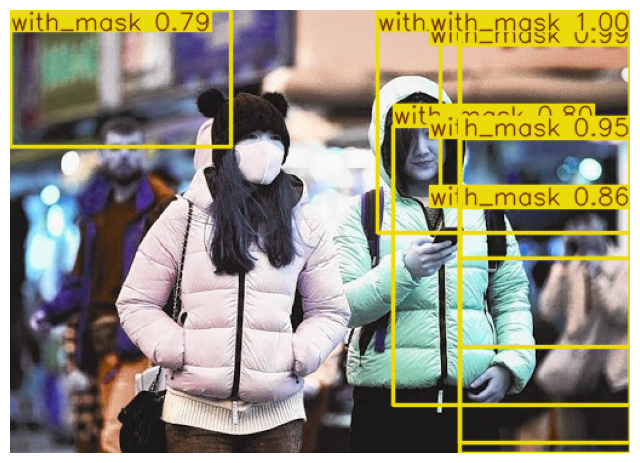

In [40]:
results = model.predict(
    source="/content/datasets/images/train/maksssksksss0.png",
    conf=0.75
)

img = results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()